# Bias Detection in NLP: Concepts and a Simulated Audit

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the main ways bias shows up in NLP models and datasets
- Quantify association gaps on a **small simulated example** (the numbers below are illustrative, not
  measured from a real model)
- Know the standard bias **mitigation strategies** and a responsible-NLP checklist
- See an association *appear* in a model that was never told about gender, and see why the standard
  "debiasing" fix zeroes the metric without moving the geometry

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 2 (bias, fairness and group metrics) and Course 07 — Unit 2, lesson 02, since word embeddings are where the association gaps measured here live.

**Used later in:** Course 10 (AIAT 124) — Unit 4, lesson 03, which detects and mitigates the same bias in generative models.

## ⚠️ Scope note

This example works with **simulated association scores** so the auditing logic is easy to follow, and then
with a **toy skip-gram we train here on a corpus we write ourselves**, so you can watch an association
form from co-occurrence alone. Neither is a real model. Measuring bias in *real* word embeddings (e.g. with
WEAT-style association tests) is what the unit exercise (`01_nlp_applications_ethics_exercise.ipynb`)
asks you to design.

---


## 🌍 Why this matters: Amazon built a recruiting model and had to throw it away

Amazon began building an automated résumé-screening engine in 2014 — rating candidates one to five stars,
like products. It was trained on ten years of résumés the company had received, and because the applicant
pool for technical roles had been overwhelmingly male, the model learned that being male was a feature of a
good candidate. Reuters reported (Jeffrey Dastin, 10 October 2018) that the system **penalized résumés
containing the word "women's"** — as in "women's chess club captain" — and **downgraded graduates of two
all-women's colleges**. Amazon's engineers edited the model to be neutral on those specific terms, could
not guarantee it would not find some other proxy for the same thing, and scrapped the project in 2017.

Two details matter more than the headline. First, **nobody wrote a rule about gender.** The association was
learned from co-occurrence — exactly the mechanism your Unit 2 embeddings used to discover that animal
words cluster together. Second, **patching the known proxies was not enough**, because a model that has a
reason to encode gender can reach it by another route.

**What goes wrong without this lesson.** A biased NLP system does not announce itself. It reports high
accuracy, passes code review, and ships — and its errors fall disproportionately on a group of people who
have no way to see it happening. Bias auditing is the practice of *going looking* for those errors before
they reach production, because no metric on your dashboard will volunteer them.

**Comparable cases in other domains:** Bolukbasi et al. found Google-News word2vec answering *man is to
computer programmer as woman is to homemaker*
([arXiv:1607.06520](https://arxiv.org/abs/1607.06520)); Prates et al. found Google Translate rendering
gender-neutral *"they are an engineer"* as *"he"* across 12 languages
([arXiv:1809.02208](https://arxiv.org/abs/1809.02208)); and closer to home, large language models are
measurably weaker on Saudi dialects than on Modern Standard Arabic — the Absher benchmark's **18,000+
multiple-choice questions across six categories**, built from dialectal words, phrases and proverbs
collected from regions across Saudi Arabia, exists precisely to turn that gap from an anecdote into a
number, and reports "notable performance gaps, particularly in tasks requiring cultural inference or
contextual understanding" ([arXiv:2507.10216](https://arxiv.org/abs/2507.10216)).

## 📥 Inputs & 📤 Outputs

**Inputs:** a small dictionary of *simulated* gender-association scores for five professions (defined in the
code below — not measured from any real model), and a corpus of ~1,080 short sentences generated from those
same five numbers, used as the skew we write into the text.

**Outputs:** an association-gap table computed from those scores and drawn as a figure; a cut-off
sensitivity curve; a six-frame storyboard of a toy skip-gram acquiring the association during training; the
association it recovers versus the skew we wrote in; a before/after test of the standard "debias the
embedding" fix; plus mitigation strategies and a responsible-NLP checklist.

---


In [1]:
# Worked example: how bias shows up in NLP systems and how practitioners audit it.
# The association scores below are SIMULATED for teaching — a real audit would
# measure them from embeddings or model outputs (see the references below).

"""
Unit 5 - Example 1: Bias Detection in NLP

This example demonstrates:
1. How bias manifests in NLP systems
2. A SIMULATED gender-bias audit (illustrative scores, not a real model)
3. Mitigation strategies
"""

print("=" * 60)
print("Example 1: Bias Detection in NLP")
print("=" * 60)

# 1. Understanding Bias in NLP
print("\n1. What is Bias in NLP?")
print("-" * 60)

bias_explanation = """
Bias in NLP can manifest as:
- Gender bias (associating certain professions with genders)
- Racial bias (stereotypical associations)
- Cultural bias (favoring certain languages/cultures)
- Socioeconomic bias (class-based associations)

"""

print(bias_explanation)

# 2. Example: Gender Bias Detection
print("\n" + "=" * 60)
print("2. Gender Bias Example (SIMULATED data)")
print("=" * 60)

# SIMULATED association scores, invented for this walkthrough.
# In a real audit these would be measured from word embeddings or model outputs.
professions = ["doctor", "nurse", "engineer", "teacher", "pilot"]
gender_associations = {
    "doctor": {"male": 0.7, "female": 0.3},
    "nurse": {"male": 0.2, "female": 0.8},
    "engineer": {"male": 0.8, "female": 0.2},
    "teacher": {"male": 0.4, "female": 0.6},
    "pilot": {"male": 0.9, "female": 0.1}
}

print("\nGender associations with professions (simulated scores):")
print("Profession | Male | Female | Bias Level")
print("-" * 50)

for profession in professions:
    male_score = gender_associations[profession]["male"]
    female_score = gender_associations[profession]["female"]
    bias_level = abs(male_score - female_score)
    bias_status = "High" if bias_level > 0.5 else "Moderate" if bias_level > 0.3 else "Low"
    
    print(f"{profession:10} | {male_score:.2f} | {female_score:.2f} | {bias_status}")

# 3. Bias Mitigation Strategies
print("\n" + "=" * 60)
print("3. Bias Mitigation Strategies")
print("=" * 60)

mitigation_strategies = [
    "Diverse training data - Ensure balanced representation", "Debiasing algorithms - Remove bias from embeddings",
    "Regular auditing - Test models for bias regularly",
    "Transparent documentation - Document known biases",
    "Fair evaluation metrics - Use fairness-aware metrics"
]

print("\nStrategies:")
for i, strategy in enumerate(mitigation_strategies, 1):
    print(f"  {i}. {strategy}")

# 4. Responsible NLP Checklist
print("\n" + "=" * 60)
print("4. Responsible NLP Checklist")
print("=" * 60)

checklist = [
    "✓ Test for bias in training data", "✓ Evaluate model on diverse test sets",
    "✓ Document known limitations",
    "✓ Provide transparency in model decisions",
    "✓ Regular bias audits",
    "✓ Include diverse perspectives in development"
]

print("\nChecklist:")
for item in checklist:
    print(f"  {item}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

Example 1: Bias Detection in NLP

1. What is Bias in NLP?
------------------------------------------------------------

Bias in NLP can manifest as:
- Gender bias (associating certain professions with genders)
- Racial bias (stereotypical associations)
- Cultural bias (favoring certain languages/cultures)
- Socioeconomic bias (class-based associations)



2. Gender Bias Example (SIMULATED data)

Gender associations with professions (simulated scores):
Profession | Male | Female | Bias Level
--------------------------------------------------
doctor     | 0.70 | 0.30 | Moderate
nurse      | 0.20 | 0.80 | High
engineer   | 0.80 | 0.20 | High
teacher    | 0.40 | 0.60 | Low
pilot      | 0.90 | 0.10 | High

3. Bias Mitigation Strategies

Strategies:
  1. Diverse training data - Ensure balanced representation
  2. Debiasing algorithms - Remove bias from embeddings
  3. Regular auditing - Test models for bias regularly
  4. Transparent documentation - Document known biases
  5. Fair evaluation

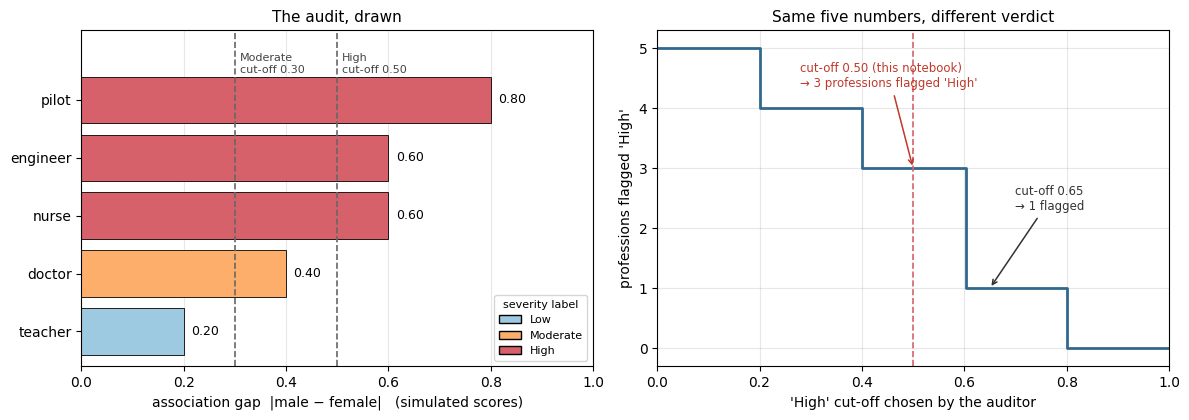

professions flagged 'High' at a few cut-offs:
  cut-off 0.15 -> 5 flagged: ['doctor', 'nurse', 'engineer', 'teacher', 'pilot']
  cut-off 0.35 -> 4 flagged: ['doctor', 'nurse', 'engineer', 'pilot']
  cut-off 0.50 -> 3 flagged: ['nurse', 'engineer', 'pilot']
  cut-off 0.65 -> 1 flagged: ['pilot']
  cut-off 0.85 -> 0 flagged: []


In [2]:
# Draw the audit we just printed. Two questions the table cannot answer on its own:
#   (a) WHAT does the gap look like per profession, and
#   (b) HOW MUCH of the verdict comes from where we put the "High" cut-off?
# WHY this figure: the severity column above looks like a measurement. It is a
# comparison against a line somebody chose. Drawing the line makes that visible.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Re-use the gaps the audit above computed (nothing new is invented here).
gaps = {p: abs(gender_associations[p]["male"] - gender_associations[p]["female"])
        for p in professions}
band_colour = {"Low": "#9ecae1", "Moderate": "#fdae6b", "High": "#d6616b"}
def severity(g):
    return "High" if g > 0.5 else ("Moderate" if g > 0.3 else "Low")

order = sorted(professions, key=lambda p: gaps[p])   # smallest gap at the bottom

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.3))

# --- Left: the gap per profession, coloured by the severity label ------------
y = np.arange(len(order))
axL.barh(y, [gaps[p] for p in order],
         color=[band_colour[severity(gaps[p])] for p in order],
         edgecolor="black", lw=0.6)
axL.set_yticks(y); axL.set_yticklabels(order)
for xv, lab in [(0.3, "Moderate\ncut-off 0.30"), (0.5, "High\ncut-off 0.50")]:
    axL.axvline(xv, ls="--", c="#666", lw=1.2)
    axL.text(xv + 0.01, 4.62, lab, fontsize=8, va="center", color="#444")
for i, p in enumerate(order):
    axL.text(gaps[p] + 0.015, i, f"{gaps[p]:.2f}", va="center", fontsize=9)
axL.set_xlim(0, 1.0); axL.set_ylim(-0.6, 5.2)
axL.set_xlabel("association gap  |male − female|   (simulated scores)")
axL.set_title("The audit, drawn", fontsize=11)
axL.grid(axis="x", alpha=0.3); axL.set_axisbelow(True)
axL.legend(handles=[Patch(facecolor=band_colour[k], edgecolor="black", label=k)
                    for k in ["Low", "Moderate", "High"]],
           loc="lower right", fontsize=8, title="severity label", title_fontsize=8)

# --- Right: re-run the SAME audit at every possible cut-off ------------------
# WHY: if the conclusion moves when the knob moves, the knob is part of the finding.
cutoffs = np.linspace(0, 1, 401)
n_flagged = [sum(1 for p in professions if gaps[p] > t) for t in cutoffs]
axR.step(cutoffs, n_flagged, where="post", lw=2, c="#31688e")
axR.axvline(0.5, ls="--", c="#d6616b", lw=1.2)
axR.annotate("cut-off 0.50 (this notebook)\n→ 3 professions flagged 'High'",
             xy=(0.5, 3), xytext=(0.28, 4.35), fontsize=8.5, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.1))
axR.annotate("cut-off 0.65\n→ 1 flagged", xy=(0.65, 1), xytext=(0.70, 2.3),
             fontsize=8.5, color="#333", arrowprops=dict(arrowstyle="->", color="#333", lw=1.1))
axR.set_xlim(0, 1); axR.set_ylim(-0.3, 5.3); axR.set_yticks(range(6))
axR.set_xlabel("'High' cut-off chosen by the auditor")
axR.set_ylabel("professions flagged 'High'")
axR.set_title("Same five numbers, different verdict", fontsize=11)
axR.grid(alpha=0.3); axR.set_axisbelow(True)

plt.tight_layout(); plt.show()

print("professions flagged 'High' at a few cut-offs:")
for t in [0.15, 0.35, 0.50, 0.65, 0.85]:
    flagged = [p for p in professions if gaps[p] > t]
    print(f"  cut-off {t:.2f} -> {len(flagged)} flagged: {flagged}")

**Read the figure.** *Left:* one bar per profession — the association gap the code printed a moment
ago. The two dashed lines are this notebook's cut-offs, 0.30 and 0.50, and a bar's colour is decided by
nothing except which side of a line it ends on: `pilot` (0.80) and the two 0.60 bars are "High", `doctor`
(0.40) is "Moderate", `teacher` (0.20) is "Low".

*Right:* the same five numbers re-audited at every possible cut-off. At 0.50 the audit reports **three**
flagged professions; slide the cut-off to 0.65 and the same data reports **one**. The staircase has no
natural step to stand on — the auditor picks one, and the headline follows the pick.

That is Discuss question 1, drawn. When you report "three professions show high gender bias", you are
reporting a fact about the data *and* a decision you made. Both belong in the write-up.

---

## Where do those five numbers actually come from?

The table above types the association scores in by hand, which makes the arithmetic easy to follow but
dodges the question that matters: **how does a score like that get into a model in the first place?**

Amazon's engineers did not write a rule about gender. Neither will we. Below we build a small corpus of
sentences in which each profession is simply *mentioned alongside* male or female words at a chosen rate —
`pilot` with male words 90% of the time, `nurse` 20% — and then train the same tiny skip-gram you built in
Unit 2, lesson 02. The training code never sees the word "gender", never sees a label, and never sees the
table above. It only plays the one game word2vec plays: predict a nearby word.

Then we measure the association back out of the learned vectors, using the gender-direction method of
Bolukbasi et al. (reference 1): project each profession's vector onto the direction that separates
*he/his/man/father/brother* from *she/her/woman/mother/sister*.

> **Why randomness is allowed here.** The repo rule is to use real data, not invented arrays. The exception
> is a lesson where the *data-generating process is the thing being taught* — and it is exactly the thing
> being taught here. We choose the skew, sample sentences from it, and check what the model recovers. The
> corpus is a controlled experiment, not a stand-in for real text; it is small, English, and ours.

Corpus: 1,080 sentences, vocabulary 23, training pairs 19,440
Note: the training data contains no labels, no genders, no professions list —
      just word ids and which word ids sat near them.



Trained 400 epochs. Cross-entropy loss 3.130 -> 2.088


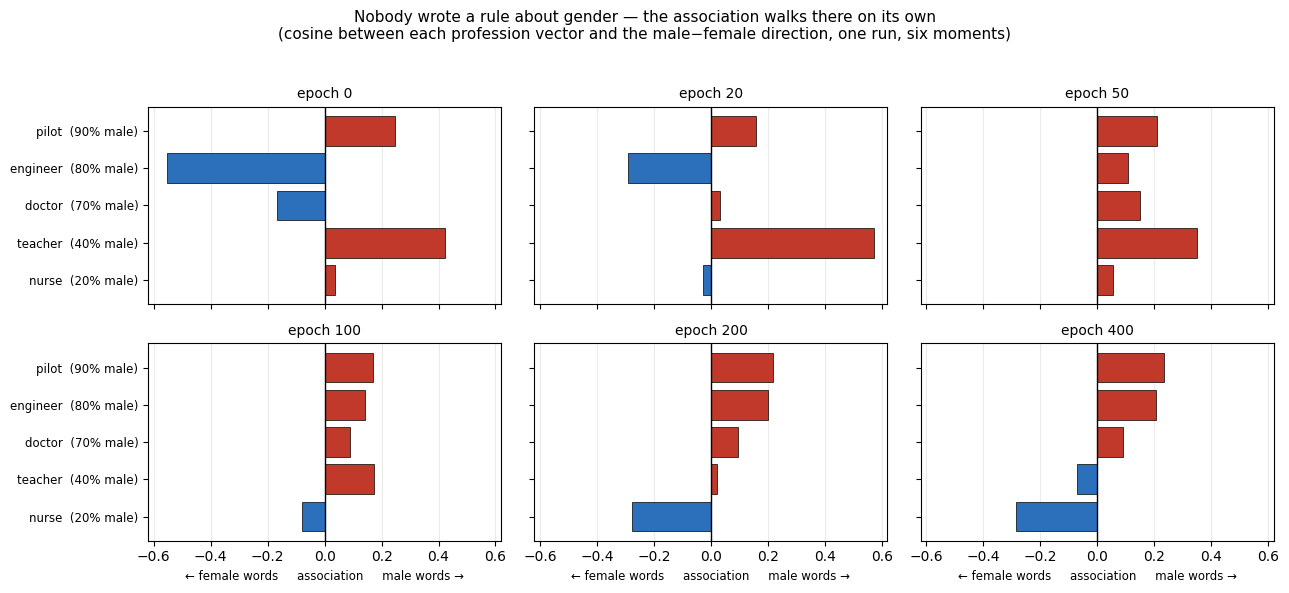


Association with the male direction at each snapshot
profession  corpus     ep 0    ep 20    ep 50   ep 100   ep 200   ep 400
doctor         70%   -0.168   +0.032   +0.152   +0.088   +0.095   +0.091
nurse          20%   +0.037   -0.027   +0.056   -0.080   -0.276   -0.287
engineer       80%   -0.554   -0.292   +0.106   +0.141   +0.199   +0.208
teacher        40%   +0.421   +0.574   +0.350   +0.173   +0.020   -0.069
pilot          90%   +0.248   +0.159   +0.209   +0.171   +0.218   +0.234


In [3]:
# Build a corpus with a KNOWN gender skew, train a tiny skip-gram on it, and
# photograph the association at six moments during training.
# WHY a frame grid rather than an animation: six still frames always render, in any
# viewer, and let you compare epoch 0 against epoch 400 side by side.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

MALE_WORDS = ["he", "his", "man", "father", "brother"]
FEMALE_WORDS = ["she", "her", "woman", "mother", "sister"]
# The skew we write into the text = the "male" column of the hand-typed table above.
male_share = {p: gender_associations[p]["male"] for p in professions}

sentences = []
# (a) Ordinary gendered sentences. These give the male and female words a
#     neighbourhood of their own, exactly as real text does. No profession appears here.
for _ in range(120):
    sentences += [["the", "man", "called", "his", "father", "yesterday"],
                  ["the", "woman", "called", "her", "mother", "yesterday"],
                  ["he", "told", "his", "brother", "the", "news"],
                  ["she", "told", "her", "sister", "the", "news"]]
# (b) Profession sentences. The ONLY thing that differs between professions is how
#     often a male vs a female word happens to appear next to them.
for p in professions:
    for _ in range(120):
        g = str(rng.choice(MALE_WORDS) if rng.random() < male_share[p]
                else rng.choice(FEMALE_WORDS))
        sentences.append(["the", p, "said", g, "would", "arrive"])

vocab = sorted({w for s in sentences for w in s})
word_to_id = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

# Extract (centre, context) pairs with a window of 2 — same recipe as Unit 2.
WINDOW = 2
centers, contexts = [], []
for s in sentences:
    for i, w in enumerate(s):
        for j in range(max(0, i - WINDOW), min(len(s), i + WINDOW + 1)):
            if j != i:
                centers.append(word_to_id[w]); contexts.append(word_to_id[s[j]])
centers = np.array(centers); contexts = np.array(contexts); N = len(centers)
print(f"Corpus: {len(sentences):,} sentences, vocabulary {V}, training pairs {N:,}")
print("Note: the training data contains no labels, no genders, no professions list —")
print("      just word ids and which word ids sat near them.")

DIM, LR, EPOCHS = 16, 2.0, 400
SNAPSHOTS = [0, 20, 50, 100, 200, 400]

W_in = rng.normal(0, 0.1, (V, DIM))    # the word vectors we keep
W_out = rng.normal(0, 0.1, (DIM, V))   # context-prediction matrix, discarded after training

male_ids = [word_to_id[w] for w in MALE_WORDS]
female_ids = [word_to_id[w] for w in FEMALE_WORDS]
prof_ids = [word_to_id[p] for p in professions]

def gender_direction(E):
    """The male−female axis, from the gendered words only (Bolukbasi et al., 2016)."""
    U = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-12)
    g = U[male_ids].mean(0) - U[female_ids].mean(0)
    return g / (np.linalg.norm(g) + 1e-12)

def association(E):
    """Cosine of each profession vector with the male−female axis. +1 male, −1 female."""
    U = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-12)
    return U[prof_ids] @ gender_direction(E)

frames, traj, epochs_rec, losses = {}, [], [], []
for e in range(EPOCHS + 1):
    if e in SNAPSHOTS:
        frames[e] = association(W_in).copy()
    if e % 10 == 0:
        traj.append(association(W_in).copy()); epochs_rec.append(e)
    if e == EPOCHS:
        break
    h = W_in[centers]                                  # centre-word vectors
    scores = h @ W_out
    scores -= scores.max(axis=1, keepdims=True)
    probs = np.exp(scores); probs /= probs.sum(axis=1, keepdims=True)
    losses.append(-np.log(probs[np.arange(N), contexts] + 1e-12).mean())
    probs[np.arange(N), contexts] -= 1.0; probs /= N   # dLoss/dScores
    grad_out = h.T @ probs
    grad_h = probs @ W_out.T
    grad_in = np.zeros_like(W_in); np.add.at(grad_in, centers, grad_h)
    W_in -= LR * grad_in; W_out -= LR * grad_out

traj = np.array(traj); epochs_rec = np.array(epochs_rec)
print(f"\nTrained {EPOCHS} epochs. Cross-entropy loss {losses[0]:.3f} -> {losses[-1]:.3f}")

# --- The frame grid: six snapshots, identical axes so the frames are comparable ---
row = sorted(range(len(professions)), key=lambda i: male_share[professions[i]])
row_labels = [f"{professions[i]}  ({male_share[professions[i]] * 100:.0f}% male)" for i in row]
MALE_C, FEM_C = "#c0392b", "#2c6fbb"

fig, axes = plt.subplots(2, 3, figsize=(13, 6.0), sharex=True, sharey=True)
for k, (e, ax) in enumerate(zip(SNAPSHOTS, axes.ravel())):
    v = frames[e][row]
    ax.barh(np.arange(5), v, color=[MALE_C if t > 0 else FEM_C for t in v],
            edgecolor="black", lw=0.5)
    ax.axvline(0, c="black", lw=1)
    ax.set_xlim(-0.62, 0.62); ax.set_ylim(-0.65, 4.65)
    ax.set_title(f"epoch {e}", fontsize=10)
    ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)
    if k % 3 == 0:
        ax.set_yticks(np.arange(5)); ax.set_yticklabels(row_labels, fontsize=8.5)
    if k >= 3:
        ax.set_xlabel("← female words     association     male words →", fontsize=8.5)
fig.suptitle("Nobody wrote a rule about gender — the association walks there on its own\n"
             "(cosine between each profession vector and the male−female direction, one run, six moments)",
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.955]); plt.show()

# --- The same six frames as a table, so the numbers can be checked by eye ---
print("\nAssociation with the male direction at each snapshot")
print(f"{'profession':<10}{'corpus':>8}" + "".join(f"{'ep ' + str(e):>9}" for e in SNAPSHOTS))
for i, p in enumerate(professions):
    print(f"{p:<10}{male_share[p] * 100:>7.0f}%"
          + "".join(f"{frames[e][i]:>+9.3f}" for e in SNAPSHOTS))

**Read the figure.** Six moments in one training run: the same five profession words, on the same axis
every time. Left of the black line means the word's vector leans toward *she / her / woman / mother /
sister*; right means it leans toward *he / his / man / father / brother*. The row labels carry the skew we
wrote into the corpus, so you can check each frame against it.

At **epoch 0** the bars are nothing but initialisation noise, and they are in the *wrong* order —
`engineer` sits far out on the female side and `teacher` far out on the male side. Frame by frame the bars
rearrange. By **epoch 400** the order matches the corpus exactly: `pilot` and `engineer` furthest right,
`doctor` just right of the line, `teacher` and `nurse` left of it.

Nothing in the training loop mentions gender, professions, or fairness. It minimises one loss: predict a
nearby word. The association is not something the model was told — it is the shape of the text, and the
model would have been *worse at its job* if it had ignored it. That is why Amazon could not fix the problem
by deleting the word "women's": the skew was not in a rule, it was in the corpus.

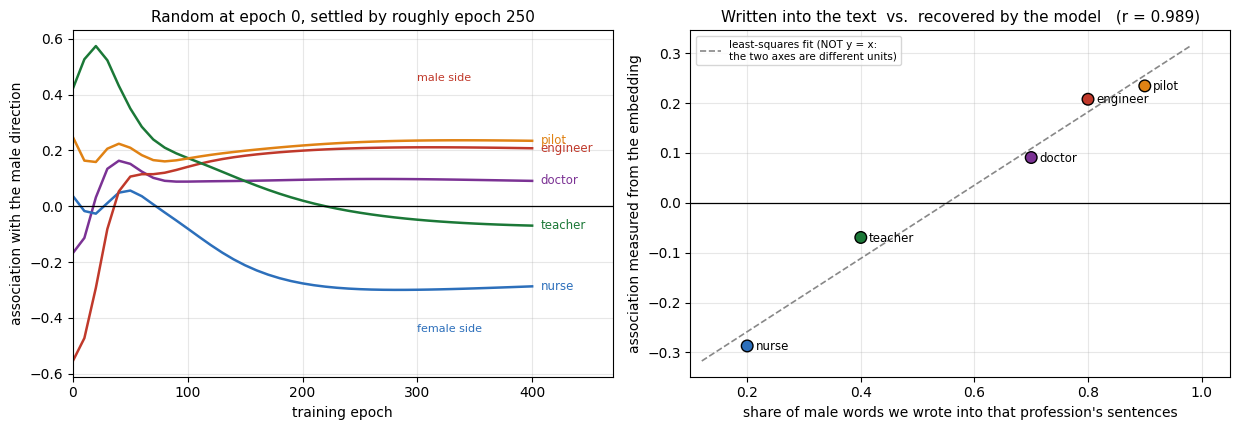

'teacher' starts at +0.421 (male side) and ends at -0.069 (female side);
it crosses zero at about epoch 230.

Pearson r between the skew we wrote in and the association measured out: 0.989
Rank order, most male-associated first:
  pilot      corpus  90% male   measured +0.234
  engineer   corpus  80% male   measured +0.208
  doctor     corpus  70% male   measured +0.091
  teacher    corpus  40% male   measured -0.069
  nurse      corpus  20% male   measured -0.287


In [4]:
# Two readings of the run: the continuous trajectory, and the input-output check.
# WHY: the frame grid shows six stills; the left panel shows what happened between
# them, and the right panel asks whether the model recovered what we put in.

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
palette = dict(zip(professions, ["#7b3294", "#2c6fbb", "#c0392b", "#1b7837", "#e08214"]))

# --- Left: association vs epoch, one line per profession ---------------------
for i, p in enumerate(professions):
    a1.plot(epochs_rec, traj[:, i], lw=1.8, color=palette[p])
    a1.annotate(p, xy=(epochs_rec[-1], traj[-1, i]), xytext=(6, 0),
                textcoords="offset points", fontsize=8.5, color=palette[p], va="center")
a1.axhline(0, c="black", lw=0.9)
a1.set_xlim(0, 470)
a1.set_xlabel("training epoch"); a1.set_ylabel("association with the male direction")
a1.set_title("Random at epoch 0, settled by roughly epoch 250", fontsize=11)
a1.grid(alpha=0.3); a1.set_axisbelow(True)
a1.text(300, 0.45, "male side", fontsize=8, color="#c0392b")
a1.text(300, -0.45, "female side", fontsize=8, color="#2c6fbb")

# --- Right: what we wrote into the text vs what the model measured -----------
xs = np.array([male_share[p] for p in professions])
ys = traj[-1]
a2.scatter(xs, ys, s=70, c=[palette[p] for p in professions], edgecolor="black", zorder=3)
for p, xv, yv in zip(professions, xs, ys):
    a2.annotate(p, xy=(xv, yv), xytext=(6, -3), textcoords="offset points", fontsize=8.5)
slope, intercept = np.polyfit(xs, ys, 1)
grid = np.linspace(0.12, 0.98, 20)
a2.plot(grid, slope * grid + intercept, ls="--", c="#888", lw=1.2, zorder=1,
        label="least-squares fit (NOT y = x:\nthe two axes are different units)")
r = np.corrcoef(xs, ys)[0, 1]
a2.axhline(0, c="black", lw=0.9); a2.set_xlim(0.1, 1.05)
a2.set_xlabel("share of male words we wrote into that profession's sentences")
a2.set_ylabel("association measured from the embedding")
a2.set_title(f"Written into the text  vs.  recovered by the model   (r = {r:.3f})", fontsize=11)
a2.legend(fontsize=7.5, loc="upper left"); a2.grid(alpha=0.3); a2.set_axisbelow(True)

plt.tight_layout(); plt.show()

# Where does each curve end up, and where does 'teacher' cross the line?
teacher_i = professions.index("teacher")
crossings = [epochs_rec[k] for k in range(1, len(epochs_rec))
             if traj[k - 1, teacher_i] > 0 >= traj[k, teacher_i]]
print(f"'teacher' starts at {traj[0, teacher_i]:+.3f} (male side) and ends at "
      f"{traj[-1, teacher_i]:+.3f} (female side);")
print(f"it crosses zero at about epoch {crossings[0] if crossings else 'n/a'}.")
print(f"\nPearson r between the skew we wrote in and the association measured out: {r:.3f}")
print("Rank order, most male-associated first:")
for i in np.argsort(-ys):
    print(f"  {professions[i]:<10} corpus {male_share[professions[i]] * 100:>3.0f}% male"
          f"   measured {ys[i]:+.3f}")

**Read the figure.** *Left:* the same run as the frame grid, but continuous. Every curve starts somewhere
random, the five fan out and cross during the first couple of hundred epochs, and all five are flat by
about epoch 250. Watch `teacher` (green): it begins high on the male side and ends below the line on the
female side — the printed line under the figure gives the epoch where it crosses.

*Right:* the check that matters. Horizontally, the share of male words we deliberately wrote into each
profession's sentences; vertically, the association a method that never saw those shares measured out of
the vectors. The five dots line up, `r` printed in the title. The dashed line is a least-squares fit, not
`y = x` — the two axes are in different units, so read the *shape*, not the slope.

**What this proves and what it does not.** It proves the association was recoverable from co-occurrence
alone: we never told the model, and it found the skew anyway, in the right order. It does **not** prove
anything about any deployed system. We built the corpus; of course the skew is in it. The value is that
you now know exactly which step introduced the bias, because you performed that step yourself.

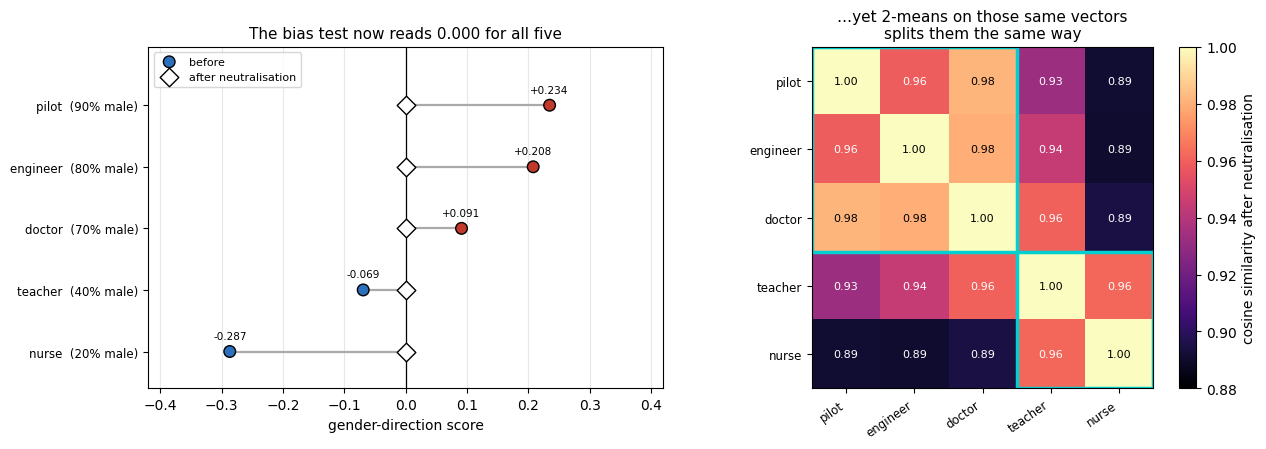

gender-direction score before: doctor +0.091, nurse -0.287, engineer +0.208, teacher -0.069, pilot +0.234
gender-direction score after : doctor +0.000, nurse -0.000, engineer +0.000, teacher -0.000, pilot +0.000

2-means on the neutralised vectors -> ['doctor', 'engineer', 'pilot']  vs  ['nurse', 'teacher']
corpus-male-skewed (>50%): ['doctor', 'engineer', 'pilot']
corpus-female-skewed (<=50%): ['nurse', 'teacher']

After neutralisation 'nurse' still sits at cosine 0.96 from 'teacher', but at most 0.89 from any of ['doctor', 'engineer', 'pilot'].
The gender axis is gone from every vector; the grouping it described is not.


In [5]:
# Now try the fix the mitigation list recommends: "remove bias from embeddings".
# WHY this cell exists: the ⚠️ section below claims debiasing mostly HIDES bias
# (Gonen & Goldberg, "Lipstick on a Pig"). Rather than ask you to take that on
# trust, we run the fix, run the test, and then look at the vectors it "cleaned".

from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

g_hat = gender_direction(W_in)
U = W_in / (np.linalg.norm(W_in, axis=1, keepdims=True) + 1e-12)
P = U[prof_ids]
before = P @ g_hat

# The standard neutralisation: subtract each vector's component along the gender axis.
P_neutral = P - np.outer(before, g_hat)
P_neutral /= np.linalg.norm(P_neutral, axis=1, keepdims=True)
after = P_neutral @ g_hat

# Cluster the NEUTRALISED vectors into two groups. No labels, no gender direction —
# if the association were really gone, this split should be arbitrary.
labels = KMeans(n_clusters=2, n_init=20, random_state=0).fit(P_neutral).labels_
clusters = [[professions[i] for i in range(len(professions)) if labels[i] == k] for k in (0, 1)]

o = sorted(range(len(professions)), key=lambda i: male_share[professions[i]])  # least male at bottom
S = P_neutral @ P_neutral.T

fig, (b1, b2) = plt.subplots(1, 2, figsize=(12.8, 4.6))

# --- Left: the score the audit would report, before and after ---------------
yy = np.arange(len(o))
for k, i in enumerate(o):
    b1.plot([before[i], after[i]], [k, k], c="#aaa", lw=1.6, zorder=1)
b1.scatter(before[o], yy, s=70, c=["#c0392b" if before[i] > 0 else "#2c6fbb" for i in o],
           edgecolor="black", zorder=3, label="before")
b1.scatter(after[o], yy, s=90, marker="D", c="white", edgecolor="black", zorder=3,
           label="after neutralisation")
for k, i in enumerate(o):
    b1.annotate(f"{before[i]:+.3f}", xy=(before[i], k), xytext=(0, 9),
                textcoords="offset points", fontsize=7.5, ha="center")
b1.axvline(0, c="black", lw=0.9)
b1.set_yticks(yy)
b1.set_yticklabels([f"{professions[i]}  ({male_share[professions[i]] * 100:.0f}% male)" for i in o],
                   fontsize=8.5)
b1.set_xlim(-0.42, 0.42); b1.set_ylim(-0.6, 4.95)
b1.set_xlabel("gender-direction score")
b1.set_title("The bias test now reads 0.000 for all five", fontsize=11)
b1.legend(fontsize=8, loc="upper left"); b1.grid(axis="x", alpha=0.3); b1.set_axisbelow(True)

# --- Right: the geometry the test can no longer see -------------------------
im = b2.imshow(S[np.ix_(o[::-1], o[::-1])], cmap="magma", vmin=0.88, vmax=1.0)
names_desc = [professions[i] for i in o[::-1]]           # most male-skewed first
b2.set_xticks(range(5)); b2.set_xticklabels(names_desc, rotation=35, ha="right", fontsize=8.5)
b2.set_yticks(range(5)); b2.set_yticklabels(names_desc, fontsize=8.5)
for a in range(5):
    for c in range(5):
        v = S[o[::-1][a], o[::-1][c]]
        b2.text(c, a, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v < 0.965 else "black")
# Draw the cluster boxes from the ACTUAL k-means result, never from an assumption.
cl_of = {professions[i]: labels[i] for i in range(len(professions))}
start = 0
for k in range(1, len(names_desc) + 1):
    if k == len(names_desc) or cl_of[names_desc[k]] != cl_of[names_desc[start]]:
        b2.add_patch(mpatches.Rectangle((start - .5, start - .5), k - start, k - start,
                                        fill=False, ec="#00d0d0", lw=2.5))
        start = k
b2.set_title("…yet 2-means on those same vectors\nsplits them the same way", fontsize=11)
plt.colorbar(im, ax=b2, fraction=0.046, label="cosine similarity after neutralisation")

plt.tight_layout(); plt.show()

print("gender-direction score before:",
      ", ".join(f"{p} {before[i]:+.3f}" for i, p in enumerate(professions)))
print("gender-direction score after :",
      ", ".join(f"{p} {after[i]:+.3f}" for i, p in enumerate(professions)))
print(f"\n2-means on the neutralised vectors -> {clusters[0]}  vs  {clusters[1]}")
print(f"corpus-male-skewed (>50%): {[p for p in professions if male_share[p] > 0.5]}")
print(f"corpus-female-skewed (<=50%): {[p for p in professions if male_share[p] <= 0.5]}")
i_n, i_t = professions.index("nurse"), professions.index("teacher")
male_skewed = [p for p in professions if male_share[p] > 0.5]
sims = [S[i_n, professions.index(p)] for p in male_skewed]
print(f"\nAfter neutralisation 'nurse' still sits at cosine {S[i_n, i_t]:.2f} from 'teacher', "
      f"but at most {max(sims):.2f} from any of {male_skewed}.")
print("The gender axis is gone from every vector; the grouping it described is not.")

**Read the figure.** *Left:* "debiasing" here is one line of algebra — subtract each profession vector's
component along the male−female axis. And it works, in the only sense the test can measure: the score that
was −0.287 for `nurse` and +0.234 for `pilot` is now **0.000 for all five**. An audit that reports this
number would sign the model off.

*Right:* the cosine similarities *between those same neutralised vectors*. The gender axis has been removed
from every one of them, yet the block structure survives — `nurse` sits far from the three male-skewed
professions and close to `teacher`. Run 2-means on the neutralised vectors, with no labels and no gender
direction to look at, and the split it returns is printed under the figure: the male-skewed professions on
one side, the female-skewed on the other. The cyan boxes are drawn from that k-means result, not assumed.

This is Gonen & Goldberg's finding reproduced in miniature: **the number you audit went to zero; the
geometry that number was measuring did not move.** A model that still encodes the association will still
act on it — and it will now do so while passing the test you used to declare it fixed. Keep that in view
when you read the mitigation list above, and when a client asks you to "debias the model" as a one-line
deliverable.

## 💬 Discuss

The auditing logic you just ran is simple. The judgement calls it hides are not.

1. This notebook labels a gap above 0.5 "High" and below 0.3 "Low". Where did those thresholds come from?
   Amazon's model was abandoned not because a number crossed a line but because of what the number meant
   for applicants. Propose a threshold for a Saudi employer's CV-screening tool — and justify it out loud
   to someone who will not get the interview.
2. `teacher` came out "Low" (0.40 / 0.60) and `pilot` "High" (0.90 / 0.10). Suppose the real workforce
   statistics matched those numbers exactly. Is a model that faithfully reproduces reality biased? Prates
   et al. found Google Translate's male skew *exceeded* what US labour statistics predicted — does that
   distinction change your answer, and what would you do differently in each of the two cases?
3. The mitigation list printed above recommends "debiasing algorithms — remove bias from embeddings". Read
   the limits section below before answering: if debiasing mostly *hides* the association rather than
   removing it, is it still worth doing? What would you tell a client who asks you to "debias the model" as
   a one-line deliverable?

---

## ✅ Summary

**What this notebook did:** walked through the *logic* of a bias audit — score associations, compute the
gap, classify the severity — on **simulated** numbers, and drew it, so you could see that the severity
label is a comparison against a cut-off somebody chose. Then it built a corpus with a known gender skew,
trained a toy skip-gram on it, and photographed the association forming over 400 epochs: the model was
never told about gender and recovered the skew anyway (r = 0.99 with what we wrote in). Finally it applied
the standard "remove the gender direction" fix, watched the metric go to exactly 0.000, and then showed
k-means still separating the male-skewed from the female-skewed professions in the supposedly neutral
space.

**What it did NOT do:** measure bias in a real model or dataset. The five scores are hand-typed and the
skip-gram is a 16-dimensional toy trained on about a thousand sentences we wrote ourselves — it
demonstrates the *mechanism*, and is evidence about nothing else. A real audit needs real embeddings or
model outputs and an association test such as WEAT — designing exactly that audit is the unit exercise.

**Next steps:**
- Complete `exercises/01_nlp_applications_ethics_exercise.ipynb`
- Recall the Unit 2 embeddings notebook: embeddings learn from co-occurrence, which is precisely how they
  absorb the biases of their training text


## ⚠️ Where this breaks

**This notebook's numbers are invented.** Five professions and ten hand-typed scores, chosen to make the
arithmetic legible. A table like this can demonstrate *auditing logic*; it can never be evidence that any
model is biased. Presenting simulated scores as an audit result would itself be an integrity failure — a
real audit measures associations from actual embeddings or actual model outputs (WEAT; Caliskan, Bryson &
Narayanan, *Science* 2017), on a documented word list, with a significance test.

**And the trained embedding is still not a real model.** The skip-gram above recovers the skew we wrote
into the corpus, which is the least surprising result available — we chose the skew. It is a controlled
demonstration that co-occurrence alone is sufficient to produce the association, on 23 word types and one
sentence template. It says nothing about the magnitude of bias in any production system, and a figure from
it must never be shown as an audit finding. Note too that the run is one seed: re-run it with a different
`default_rng` value and the epoch-0 frame, the crossing points, and the exact final numbers all move.

**"Debiasing" mostly hides the bias.** The mitigation list above recommends removing bias from embeddings.
Gonen & Goldberg tested that claim directly in *Lipstick on a Pig*
([arXiv:1903.03862](https://arxiv.org/abs/1903.03862)): after standard debiasing, "the gender bias
information is still reflected in the distances between 'gender-neutralized' words … and can be recovered
from them", so "the actual effect is mostly hiding the bias, not removing it". A model that still encodes
the association will still act on it, while passing the very test you used to declare it fixed. That is
worse than not debiasing at all, because it buys false confidence.

**A gap score is not a harm.** Blodgett et al.'s critical survey of "bias" in NLP
([arXiv:2005.14050](https://arxiv.org/abs/2005.14050)) found that the field routinely reports association
metrics without stating who is harmed, how, and why that harm is wrong. Before reporting a number, write
the sentence: *"in this deployment, this system will do X to these people."* If you cannot write it, you
have measured a curiosity, not a risk.

**Where the framework itself does not transfer.** Almost all published bias measurement is English,
binary-gendered and Western. Saudi and Gulf deployments raise categories no standard word list covers:
dialect and region, tribal and family-name signals, nationality of expatriate workers, MSA-versus-
colloquial register. There is no off-the-shelf test for these. Arabic benchmark work is starting to close
the measurement gap — a survey of Arabic benchmarks and their blind spots
([arXiv:2510.13430](https://arxiv.org/abs/2510.13430)) and QIMMA's argument for validating the benchmark
before ranking models with it ([arXiv:2604.03395](https://arxiv.org/abs/2604.03395)) — but designing a
locally meaningful audit is still engineering work, not a library call.

**And one 2026 risk this checklist predates.** A text pipeline that reads untrusted documents can be
*steered* by them: indirect prompt injection, where instructions are hidden inside the content a model is
asked to process, was named and demonstrated by Greshake et al.
([arXiv:2302.12173](https://arxiv.org/abs/2302.12173)), and prompt injection sits at **number one** on the
OWASP Top 10 for LLM Applications (2025 edition, LLM01,
<https://owasp.org/www-project-top-10-for-large-language-model-applications/>). Responsible NLP in 2026
means auditing for manipulation as well as for bias.

## 🔭 State of the field (2026)

The audit *logic* above is unchanged. What changed is the evidence a 2026 audit is expected to produce, and
three expectations are now standard. First, **the benchmark is validated before any model is ranked with
it** — QIMMA's Arabic work surfaced and resolved systematic quality problems in existing test sets first, on
the argument that a leaderboard built on an unchecked benchmark mostly measures the benchmark
([arXiv:2604.03395](https://arxiv.org/abs/2604.03395)). Second, **the score arrives with an interval**:
where a large model is used to grade outputs, judge-based numbers need bias correction and stated
uncertainty before anyone acts on them ([arXiv:2511.21140](https://arxiv.org/abs/2511.21140)). Third,
**the report is a documented artifact** rather than a number on a slide — evaluation cards do for an
evaluation what model cards did for a model: state what was measured, on whose data, and what the result
does not license ([arXiv:2606.09809](https://arxiv.org/abs/2606.09809)).

None of that replaces this notebook. You cannot put an interval around a gap you have not defined, and the
association → gap → severity chain here is that definition, done slowly enough to argue with. Do the logic
by hand once; then never publish it without the benchmark provenance and the uncertainty attached.


## 📚 References

The papers that established bias measurement in NLP, the critical view of the field, and the 2025-2026 evaluation-reporting literature:

1. Bolukbasi, T., Chang, K.-W., Zou, J., Saligrama, V., & Kalai, A. (2016). *Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings*. NeurIPS 2016. [arXiv:1607.06520](https://arxiv.org/abs/1607.06520)
2. Caliskan, A., Bryson, J. J., & Narayanan, A. (2017). *Semantics Derived Automatically from Language Corpora Contain Human-Like Biases*. Science, 356(6334), 183-186.
3. Blodgett, S. L., Barocas, S., Daume III, H., & Wallach, H. (2020). *Language (Technology) is Power: A Critical Survey of "Bias" in NLP*. ACL 2020. [arXiv:2005.14050](https://arxiv.org/abs/2005.14050)
4. Bender, E. M., Gebru, T., McMillan-Major, A., & Mitchell, M. (2021). *On the Dangers of Stochastic Parrots: Can Language Models Be Too Big?* ACM FAccT 2021.
5. Al-Monef, R., Alhuzali, H., Alturayeif, N., & Alasmari, A. (2025). *From Words to Proverbs: Evaluating LLMs Linguistic and Cultural Competence in Saudi Dialects with Absher*. [arXiv:2507.10216](https://arxiv.org/abs/2507.10216) — the Absher benchmark; makes the Saudi-dialect gap measurable rather than anecdotal.
6. AlQadi, L., Alzubaidi, A., Alyafeai, M., Alobeidli, H., Alhammadi, M., et al. (2026). *Are Arabic Benchmarks Reliable? QIMMA's Quality-First Approach to LLM Evaluation*. [arXiv:2604.03395](https://arxiv.org/abs/2604.03395) — validate the benchmark before you rank models with it.
7. Ghosh, A., Reuel, A., Chim, J., Kennedy, W. M., Yadav, S., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. [arXiv:2606.09809](https://arxiv.org/abs/2606.09809) — for an evaluation, what a model card is for a model.
